# Lab 2: Forecasting Measle Infections with MLP (Basic NNs) and CNN

### Created by Wei Jin and Zewen Liu

Please feel free to reach out with questions or suggestions: wei.jin@emory.edu and zewen.liu@emory.edu



## Introduction

In this tutorial, we will focus on the buiding, training and evaluating of the MLP and CNN models. Following the previous [R Lab](https://colab.research.google.com/github/WyattGMadden/intro_to_ml_for_id_emory/blob/main/tutorials/semi_mechanistic_modeling_and_ml_for_measles_in_r/semi_mechanistic_modeling_and_ml_for_measles_in_r.ipynb), the measle dataset is used.

We also provide a brief introduction to the theory and coding of these models. They won't affect the following case study, so please feel free to skip them if you want to.

For more reading materials, please refer to [[1](https://link.springer.com/article/10.1007/s10489-021-02359-6)] and [[2](https://www.sciencedirect.com/science/article/pii/S2211379721002904)].

## Settings of time series forecasting

For time series forecasting, the model will accept a period of history data within the lookback window and perform prediction of K steps ahead, which is the horizon.

* Model input size: batch * lookback window size * channels
* Model output size: batch * horizon (horizon is like a 5-day forcast or 1-week or 1-month forcast, this is horizon)

![TSF](https://drive.google.com/uc?id=11uNbfweHL84997hGuygbHvISTf31S2Ld)
<!-- ![TSF](TSF.png) -->

## Multilayer Perceptron (MLP) or Basic NNs

### Theory

3. Define Neural Network Layers and Activation Function

We will create two linear (fully connected) layers and one ReLU activation function.

The first linear layer (`fc1`) will transform the input from 10 features to 5 features.
The ReLU activation function will add non-linearity to the network.
The second linear layer (`fc2`) will transform the 5 features down to a single output feature.

**Linear Layers**: Layers that perform affine transformations, defined by nn.Linear.

**ReLU Activation**
: A non-linear activation function that sets all negative values to zero.

A Multilayer Perceptron (MLP) is a class of feedforward artificial neural networks. It consists of at least three layers of nodes: an input layer, one or more hidden layers, and an output layer. Except for the input nodes, each node is a neuron that uses a nonlinear activation function.

#### Key Components

1. Input Layer: This layer consists of neurons that receive the input features of the dataset. Each neuron represents one feature.
2.	Hidden Layers: These layers are situated between the input and output layers. Neurons in these layers transform the input data by applying weights and biases, followed by an activation function. The number of hidden layers and the number of neurons in each layer can vary depending on the specific use case.
3.	Output Layer: This layer produces the final prediction. For regression tasks, it might have a single neuron with a linear activation function. For classification tasks, it may have as many neurons as there are classes, often using a softmax activation function to produce probabilities.

####  Forward Propagation

* Weighted Sum: Each neuron receives input from the previous layer, calculates a weighted sum of the inputs, adds a bias term, and passes the result through an activation function.
For a neuron  j  in layer  l , the weighted sum of its inputs is calculated as:
 $z_j^{(l)} = \sum_{i=1}^{n_{l-1}} w_{ij}^{(l)} a_i^{(l-1)} + b_j^{(l)} $
where:

  * $z_j^{(l)}$  is the weighted sum for neuron  j  in layer  l .
  * $w_{ij}^{(l)}$  is the weight connecting neuron  i  in layer  l-1  to neuron  j  in layer  l .
  * $a_i^{(l-1)}$  is the activation of neuron  i  in the previous layer  l-1 .
  * $b_j^{(l)}$  is the bias term for neuron  j  in layer  l .
  * $n_{l-1}$  is the number of neurons in the previous layer  l-1 .
* Activation Function: Common choices include ReLU (Rectified Linear Unit), Sigmoid, and Tanh. These functions introduce non-linearity into the model, enabling it to learn complex patterns.
The activation  $a_j^{(l)}$  for neuron  j  in layer  l  is given by applying an activation function  f  to the weighted sum:
 $a_j^{(l)} = f(z_j^{(l)}) $. Common activation functions:

  * ReLU (Rectified Linear Unit):  $f(z) = \max(0, z) $
  * Sigmoid:  $f(z) = \frac{1}{1 + e^{-z}} $
  * Tanh:  $f(z) = \tanh(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}} $

<img src="https://drive.google.com/uc?id=121rYIAOwjsOWGJMDIvge17qYSPv0G73M" alt="mlp" width="800" height="600">
<!-- <img src="nn1.png" alt="mlp" width="800" height="600"> -->

### Step by Step Guide

1. Import Libraries

In [1]:
import torch
import torch.nn as nn

The `torch.nn` module in PyTorch provides a set of classes and functions to build and train neural networks. It includes layers, activation functions, loss functions, and more:
* Layers: `torch.nn` provides various types of layers such as `nn.Linear`, `nn.Conv1d`, `nn.Conv2d`, etc.
* Activation Functions: Functions like `nn.ReLU`, `nn.Sigmoid`, etc., are used to introduce non-linearity in the network.

2. Define Input Data

We will use a sample 1D input data which can be thought of as a batch of one sequence with a length of 10. This input data will be a PyTorch tensor.

In [2]:
# Sample 1D input data (e.g., a batch of 1 sequence with length 10)
input_data = torch.tensor([[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]])  # (batch_size, sequence_length)

In [141]:
input_data

tensor([[ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.]])

In [3]:
# Define the linear layers and activation function
fc1 = nn.Linear(in_features=10, out_features=5)
relu = nn.ReLU()
fc2 = nn.Linear(in_features=5, out_features=1)

4. Forward Pass Through the Network

**Forward Pass:** The process of passing data through the network to obtain the output.

Now, we will pass the input data through the defined layers in sequence.

First, the input data passes through the first fully connected layer (`fc1`).
Then, the output of `fc1` is passed through the ReLU activation function.
Finally, the output of the ReLU activation is passed through the second fully connected layer (`fc2`).

In [4]:
# Forward pass through the first fully connected layer
output_fc1 = fc1(input_data)
# Apply ReLU activation
output_relu = relu(output_fc1)
# Forward pass through the second fully connected layer
output_fc2 = fc2(output_relu) # 1-dimensional

5. Print the Results

We will print the input data, the intermediate outputs after the first linear layer and the ReLU activation, and the final output after the second linear layer.



In [5]:
# Print the input, intermediate outputs, and final output
print("Input Data:")
print(input_data.detach().numpy()) # Convert the input tensor to a NumPy array and print it

print("\nOutput after first linear layer (fc1):")
print(output_fc1.detach().numpy())

print("\nOutput after ReLU activation:")
print(output_relu.detach().numpy())

print("\nFinal Output after second linear layer (fc2):")
print(output_fc2.detach().numpy())

Input Data:
[[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]]

Output after first linear layer (fc1):
[[-2.9368377   4.280468    0.14816986 -2.2198863  -3.5955217 ]]

Output after ReLU activation:
[[0.         4.280468   0.14816986 0.         0.        ]]

Final Output after second linear layer (fc2):
[[-1.829845]]


## Convolutional Neural Networks (CNN)

### Theory

Convolutional Neural Networks (CNNs) are designed to process and learn from data with a grid-like topology, such as images (2D grids of pixels) or time series data (1D grids of values). They leverage the mathematical operation of convolution to extract features from the input data.

$\textbf{Convolution Operation}$

The convolution operation involves a filter (or kernel) sliding over the input data to produce a feature map. Mathematically, for a 1D input  x  and a 1D kernel  w , the convolution operation is defined as:

 $(x * w)(t) = \sum_{i=-\infty}^{\infty} x(i) \cdot w(t - i)$

However, in practice, the input and the kernel are finite, so the operation is often written as:

 $(x * w)(t) = \sum_{i=0}^{k-1} x(t + i) \cdot w(i) $

where  k  is the size of the kernel.
<!-- https://stackoverflow.com/questions/55701788/should-a-1d-cnn-need-padding-to-retain-input-length -->

![](https://drive.google.com/uc?id=12ZmmMZHAdM_qr7WAMZbXA17lxxL6OXgN)
<!-- ![1d-cnn.png](attachment:1d-cnn.png) -->

For a 2D input (e.g., an image) and a 2D kernel, the convolution is defined as:

 $(X * W)(i, j) = \sum_{m=0}^{M-1} \sum_{n=0}^{N-1} X(i+m, j+n) \cdot W(m, n) $

where  X  is the input image,  W  is the kernel, and  M  and  N  are the dimensions of the kernel.

<!-- https://medium.com/@draj0718/zero-padding-in-convolutional-neural-networks-bf1410438e99 -->

![](https://drive.google.com/uc?id=12EhNbGJS6rK6DasWhc0vHl8PvAI0UYjm)
<!-- ![kernel.png](attachment:kernel.png) -->

$\textbf{Layers in CNNs}$

1.	Convolutional Layer:
	* Applies multiple convolutional filters to the input.
	*	Each filter produces a feature map.
	*	The output of this layer is a set of feature maps.
2.	Activation Function (ReLU):
	*	Introduces non-linearity into the model.
	*	ReLU (Rectified Linear Unit) is defined as  $\text{ReLU}(x) = \max(0, x)$ .
3.	Pooling Layer:
	*	Reduces the spatial dimensions of the feature maps.
	*	Common types are max pooling and average pooling.
4.	Fully Connected Layer:
	*	Each neuron is connected to every neuron in the previous layer.
	*	This layer performs the final classification or regression task.
5.	Dropout:
	*	Randomly sets a fraction of the input units to 0 at each update during training time.
	*	Prevents overfitting.

$\textbf{Forward Pass}$

In a forward pass through a CNN:

*	The input data is convolved with multiple filters in the convolutional layers.
*	The activation functions are applied to introduce non-linearity.
*	Pooling layers reduce the dimensionality of the data.
*	Fully connected layers combine the extracted features for the final output.

![](https://drive.google.com/uc?id=12hB3tMWPWiphzmbVW2bq3DSvelLlhbBA)
<!-- ![CNN.png](attachment:CNN.png) -->



### 1D Convolution

1. Import Libraries and Define Data

In [6]:
import torch
import torch.nn as nn

# Sample 1D input data (e.g., a batch of 1 sequence with 1 channel and length 10)
input_data = torch.tensor([[[5.0, 2.0, 1.0, 4.0, 3.0, 6.0, 0.0, 1.0, 9.0, 10.0]]])  # (batch_size, num_channels, sequence_length)


In [7]:
input_data

tensor([[[ 5.,  2.,  1.,  4.,  3.,  6.,  0.,  1.,  9., 10.]]])

2. Define a 1D Convolutional Layer

We will create a 1D convolutional layer with the following parameters:

* `in_channels=1`: The number of channels in the input data.
* `out_channels=1`: The number of channels produced by the convolution.
* `kernel_size=3`: The size of the convolving kernel.
* `stride=1`: The stride of the convolution.
* `padding=1`: The amount of zero-padding added to both sides of the input.

In [8]:
# Define a 1D convolutional layer
conv1d = nn.Conv1d(in_channels=1,
                   out_channels=1,
                   kernel_size=3,
                   stride=1,
                   padding=1)

3. Initialize the Convolutional Layer Weights and Bias

For demonstration purposes, we will manually set the weights and bias of the convolutional layer to specific values.



In [106]:
# Initialize the convolutional layer weights and bias for demonstration purposes
with torch.no_grad():
    conv1d.weight = nn.Parameter(torch.tensor([[[1.0, 0.0, -1.0]]]))  # Example kernel
    conv1d.bias = nn.Parameter(torch.tensor([0.0]))  # No bias

4. Apply the Convolutional Layer to the Input Data

We will apply the defined convolutional layer to the input data to obtain the output data.

In [107]:
# Apply the convolutional layer to the input data
output_data = conv1d(input_data)

5. Print the Results

We will print the input data, the kernel (weights) of the convolutional layer, and the output data.

In [108]:
# Print the input and output data
print("Input Data:")
print(input_data.detach().numpy())

print("\nKernel (Weights):")
print(conv1d.weight.detach().numpy())

print("\nOutput Data:")
print(output_data.detach().numpy())

Input Data:
[[[ 5.  2.  1.  4.  3.  6.  0.  1.  9. 10.]]]

Kernel (Weights):
[[[ 1.  0. -1.]]]

Output Data:
[[[-2.  4. -2. -2. -2.  3.  5. -9. -9.  9.]]]


## Case Study: Predicting Future Infections with Measle Dataset

### 0. Import packages and define configurations

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
from torch.utils.data import DataLoader, Dataset

# global configs
lookback = 16 # history weeks
horizon = 1 # future weeks
batch_size = 16
learning_rate = 1e-3
num_epochs = 1000


### 1. Load time series data

In [10]:
# URL of the data file stored in Google Drive
url_data = "https://drive.google.com/uc?export=download&id=12WpPH-FwJ5Os11IGKLkzVgENglQbu37a"

# Retrieve the file from the URL and save it locally as 'measles.pt'
urllib.request.urlretrieve(url_data, 'measles.pt')


# Load the saved data file into a PyTorch tensor
raw_data = torch.load('measles.pt', weights_only=False)

# Print the keys of the loaded data to understand its structure
print(raw_data.keys())

dict_keys(['weekly_infection', 'anual_population', 'anual_birth', 'coordinates'])


In [11]:
raw_data['coordinates']

,Long,Lat
rownames,,
Abingdon,-1.285,51.673
Abram,-2.597,53.508
Accrington,-2.372,53.752
Acton,-0.265,51.510
Adlington,-2.598,53.617
...,...,...
Towyn,-4.078,52.587
Tredegar,-3.240,51.777
Usk,-2.905,51.698


In [12]:
# Extract the 'weekly_infection' data from the loaded dataset
weekly_infection = raw_data['weekly_infection']
weekly_infection

,Abingdon,Abram,Accrington,Acton,Adlington,Adwick.le.Street,Aldeburgh,Alderley.Edge,Aldershot,Aldridge,...,Rhymney,Risca,Ruthin,Swansea,Tenby,Towyn,Tredegar,Usk,Welshpool,Wrexham
rownames,,,,,,,,,,,,,,,,,,,,,
44.01923,0,0,0,0,0,0,0,0,0,2,...,0,0,0,0,0,0,1,0,0,0
44.03846,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1
44.05769,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
44.07692,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,2,0,0,0
44.09615,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,6,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65.15385,19,0,7,49,0,0,0,3,39,31,...,0,1,2,7,0,0,0,0,0,4
65.17308,37,0,7,42,0,0,0,0,45,23,...,0,0,2,29,0,0,0,0,0,7
65.19231,39,1,12,49,0,0,0,0,18,9,...,0,3,1,11,0,0,0,0,0,1


### 2. Data preprocessing

In [13]:
# Data Normalization

# Convert the weekly infection data to a PyTorch FloatTensor and transpose it
data = torch.FloatTensor(np.array(weekly_infection)).T

# Calculate the mean of the data along the second dimension (dim=1), keeping the dimensions for broadcasting
means = data.mean(dim=1, keepdim=True)

# Calculate the standard deviation of the data along the second dimension (dim=1), keeping the dimensions for broadcasting
stds = data.std(dim=1, keepdim=True)

# Normalize the data by subtracting the mean and dividing by the standard deviation
norm_data = (data-means)/stds
print(norm_data)

tensor([[-0.3539, -0.3539, -0.3539,  ...,  4.1554,  2.9992, -0.1226],
        [-0.3915, -0.3915, -0.3915,  ..., -0.0680, -0.3915, -0.3915],
        [-0.4557, -0.4557, -0.4557,  ...,  0.6841, -0.0758,  0.9690],
        ...,
        [-0.2516, -0.2516, -0.2516,  ..., -0.2516, -0.2516, -0.2516],
        [-0.2317, -0.2317, -0.2317,  ..., -0.2317, -0.2317, -0.2317],
        [-0.4461, -0.3791, -0.4461,  ..., -0.3791, -0.0438,  0.1573]])


In [14]:
norm_data.shape

torch.Size([946, 1108])

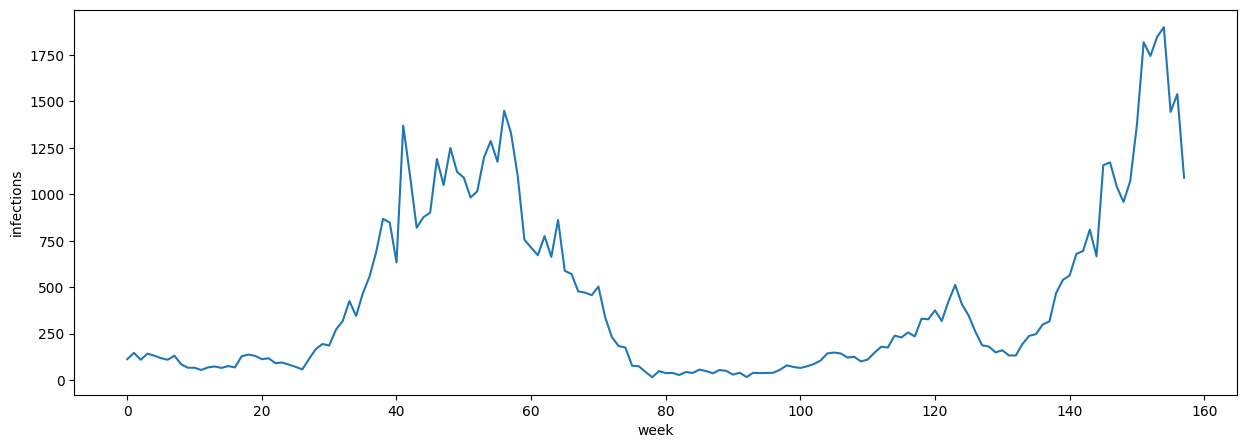

In [15]:
# Visualize a period of infections in London

# Create a new figure with a specific size (15 inches wide and 5 inches tall)
plt.figure(figsize=(15,5))

plt.plot(data[441, 950:]) # Plot the infection data for London from week 950 onward
plt.xlabel('week')  # Label the x-axis as 'week'
plt.ylabel('infections')  # Label the y-axis as 'infections'
plt.show()  # Display the plot

In [16]:
# This class is used to perform normalization and store the mean and variance of the input samples, which can later be denormalized
# This Python class, written using PyTorch, defines a reusable object for normalizing and denormalizing data.
# It’s similar in purpose to R’s scale() function, but with more control and structured in an object-oriented way.
class normalization():
    def __init__(self, eps=1e-5) -> None:
        self.eps = eps # Small value to avoid division by zero
        self.mean = None  # Placeholder for the mean of the input data
        self.std = None # Placeholder for the standard deviation of the input data

    # Get the mean and standard variance of the inputs
    def _get_statistics(self, x):
        # Determine the dimensions to reduce over (excluding the batch and feature dimensions)
        dim2reduce = tuple(range(1, x.ndim-1))
        self.mean = torch.mean(x, dim=dim2reduce, keepdim=True).detach()
        self.stdev = torch.sqrt(torch.var(x, dim=dim2reduce, keepdim=True, unbiased=False) + self.eps).detach()

    # Perform normalization
    def norm(self, x):
        self._get_statistics(x)
        x = x - self.mean
        x = x / self.stdev
        return x

    # Perform denormalization
    def denorm(self, x):
        x = x * self.stdev
        x = x + self.mean
        return x

# initialize normalization class
normalize = normalization()

In [18]:
# define a class for the measle dataset
class measle_dataset(Dataset):
    def __init__(self, data, lookback, horizon):
        self.full_data = data
        self.num_time_steps = data.shape[0]
        self.lookback = lookback
        self.horizon = horizon
        self.data = self.split(self.full_data, self.lookback, self.horizon)

    # Cut the original sequence using a slide window: L->Nx(looback+horizon)
    def split(self, data, lookback, horizon):
        tmp = []
        for i in range(len(data) - lookback - horizon):
            history = data[i : i+self.lookback]
            future = data[i+lookback : i+lookback+horizon]
            tmp.append((history, future))
        return tmp

    def __len__(self):
        return len(self.data)

    # defines how to output data in DataLoader (Pytorch DataLoader receives the output of this function and then output the batched data)
    def __getitem__(self, index):
        history_data, label = self.data[index]
        return history_data, label


In [20]:
# Get measle data for one city: e.g. London
city_index = 441
single_region_data = data[city_index,:]
print("total time steps: ", len(single_region_data))
print(single_region_data)

total time steps:  1108
tensor([  82.,   98.,  118.,  ..., 1444., 1540., 1089.])


In [119]:
# split data into training and testing set (For real-time forecasting, the period of training set should be earlier than the testing set)
# length of data
total_steps = len(single_region_data)

# proportion of training sample
train_rate = 0.7
train_steps = int(total_steps*train_rate)

# get training and testing split
train_data = single_region_data[:train_steps]
test_data = single_region_data[train_steps:]

# Load the data using the predifined measle_dataset class
train_dataset = measle_dataset(train_data, lookback, horizon)
test_dataset = measle_dataset(test_data, lookback, horizon)

# Load the measle datasets into pytorch DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [120]:
train_data.shape, test_data.shape

(torch.Size([775]), torch.Size([333]))

### 3. Building MLP Model or Basic NNs

In [121]:
class MLP(nn.Module):
    def __init__(self, lookback, horizon, hidden_sizes=[256,128,64]):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(lookback, hidden_sizes[0])  # First hidden layer
        self.fc2 = nn.Linear(hidden_sizes[0], hidden_sizes[1])    # Second hidden layer
        self.fc3 = nn.Linear(hidden_sizes[1], hidden_sizes[2])     # Third hidden layer
        self.fc4 = nn.Linear(hidden_sizes[2], horizon)      # Output layer

        self.relu = nn.ReLU()             # ReLU activation function

    def forward(self, x):
        # Forward pass through each layer with ReLU activation
        x = self.relu(self.fc1(x))  # First layer
        x = self.relu(self.fc2(x))  # Second layer
        x = self.relu(self.fc3(x))  # Third layer
        # x = self.dropout(x)
        x = self.fc4(x)             # Output layer (no activation)

        return x # shape: batch*horizon

# initialize model
MLP_model = MLP(lookback, horizon, hidden_sizes=[256,128,64]).cuda()

### 4. Building CNN Model

In [122]:
# Define a 1D Convolutional Neural Network (CNN) class
class CNN1D(nn.Module):
    def __init__(self, lookback, horizon, hidden_sizes=[16,32,128]):
        super(CNN1D, self).__init__()
        self.lookback = lookback  # Number of past time steps to consider (history)
        self.horizon = horizon   # Number of future time steps to predict
        self.conv1 = nn.Conv1d(in_channels=1,
                               out_channels=hidden_sizes[0],
                               kernel_size=3,
                               stride=1,
                               padding=1) # first convolutional layer
        self.conv2 = nn.Conv1d(in_channels=hidden_sizes[0],
                               out_channels=hidden_sizes[1],
                               kernel_size=3,
                               stride=1,
                               padding=1)# second  convolutional layer
        self.pool = nn.MaxPool1d(kernel_size=2,
                                 stride=2,
                                 padding=0) # Max Pooling
        self.fc1 = nn.Linear(hidden_sizes[1] * (lookback // 4), hidden_sizes[2]) # first linear layer
        self.fc2 = nn.Linear(hidden_sizes[2], horizon) # second linear layer
        self.relu = nn.ReLU()             # ReLU activation function

    def forward(self, x):
        # feature extrction using convolution layers
        x = x.unsqueeze(1)
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        # flatten and perform prediction using fully connected layers
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# initialize model
CNN_model = CNN1D(lookback, horizon, hidden_sizes=[16,32,128]).cuda()

### 5. Model Training

In [123]:
# training function
def train(model, epochs, criterion=nn.MSELoss()):
    # Initialize optimizer
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # save the average loss for every epoch
    history_loss = []

    # start training
    for epoch in range(epochs):
        avg_loss = 0 # average loss in one epoch
        counter = 0 # save the number of samples

        for inputs, labels in train_loader:
            # normalize the inputs
            norm_inputs = normalize.norm(inputs.cuda())

            # clear the saved gradient in the optimizer
            optimizer.zero_grad()
            # forward function
            outputs = model(norm_inputs)
            # denormalize the outputs of the model
            predictions = normalize.denorm(outputs)

            # compare with the ground truth and get current MSE loss
            loss = criterion(predictions, labels.cuda())

            # back propogate the loss and compute gradient for each variable
            loss.backward()
            # update the variables according to the gradients
            optimizer.step()
            # sum up the samples; inputs.shape[0] is the batch size
            counter += inputs.shape[0]
            # compute average loss
            avg_loss += loss.item()

        # save average loss of the current epoch
        avg_loss /= counter
        history_loss.append(avg_loss)
        # print loss
        if epoch%100==0: # Print loss every 100 epochs
            print(f'Epoch [{epoch + 1}/{epochs}], Loss: {avg_loss}')

    # plot the loss curve
    plt.figure()
    plt.plot(history_loss)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Training Loss over Epochs with {criterion.__class__.__name__}') # Add title with loss function name
    plt.show()

    return model

In [124]:
#  for inputs, labels in train_loader:
#     print(inputs.shape, labels.shape)
#     break

Epoch [1/1000], Loss: 5659.455554005967
Epoch [101/1000], Loss: 295.69035858717945
Epoch [201/1000], Loss: 165.7116305469523
Epoch [301/1000], Loss: 148.27764697313938
Epoch [401/1000], Loss: 134.67433657683924
Epoch [501/1000], Loss: 64.80311768665163
Epoch [601/1000], Loss: 54.39821661996967
Epoch [701/1000], Loss: 46.89931675249165
Epoch [801/1000], Loss: 35.10595242140476
Epoch [901/1000], Loss: 37.314705539190044


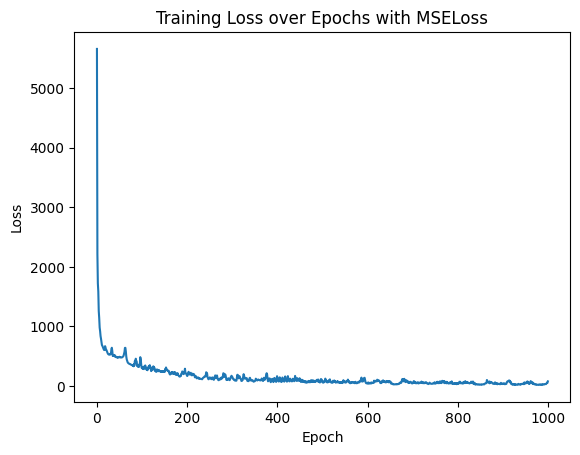

In [125]:
# Train CNN
CNN_model = train(CNN_model, epochs=num_epochs)

Epoch [1/1000], Loss: 4277.455048654199
Epoch [101/1000], Loss: 181.32148575594053
Epoch [201/1000], Loss: 93.84283036606922
Epoch [301/1000], Loss: 78.51789148375981
Epoch [401/1000], Loss: 30.799136541764152
Epoch [501/1000], Loss: 41.461273354402
Epoch [601/1000], Loss: 47.65713407370534
Epoch [701/1000], Loss: 29.351729028143165
Epoch [801/1000], Loss: 28.46591678709971
Epoch [901/1000], Loss: 34.2007740393163


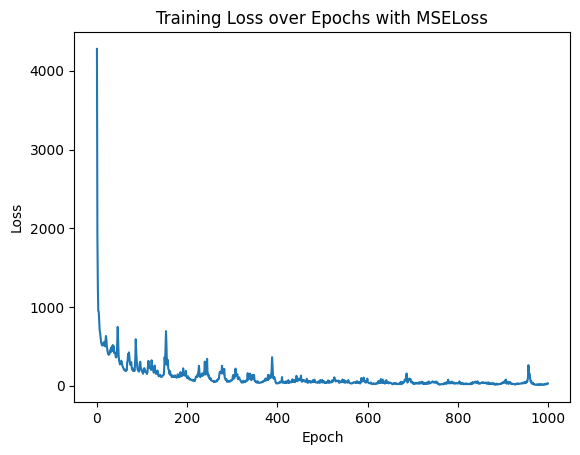

In [126]:
# Train MLP
MLP_model = train(MLP_model, epochs=num_epochs)

### 6.Model Evaluation

In [127]:
# testing function
def test(model, loader, criterion):
    # Initialize an empty tensor to store predictions and groundtruth
    predictions = torch.FloatTensor()
    groundtruth = torch.FloatTensor()


    with torch.no_grad(): # during inference, we don't need gradients to update parameters (saving memory)
        avg_loss = 0
        counter = 0
        for inputs, labels in loader:
            norm_inputs = normalize.norm(inputs) # Normalize the input data
            outputs = model(norm_inputs.cuda()) # Forward pass: compute the model output
            preds = normalize.denorm(outputs.detach().cpu())  # Denormalize the model output

            loss = criterion(preds, labels)

            groundtruth = torch.cat([groundtruth, labels])
            predictions = torch.cat([predictions, preds])
            counter += inputs.shape[0]
            avg_loss += loss.item()

        avg_loss /= counter

        print(f'Evaluation: {avg_loss}')
    return predictions, groundtruth

# plotting function
def plot(model, loader):

    # # Initialize an empty tensor to store predictions and groundtruth
    predictions = torch.FloatTensor()
    groundtruth = torch.FloatTensor()

    with torch.no_grad():
        data = loader.dataset.full_data

        # Iterate over the dataset with a step size of horizon
        for i in range(0, len(data) - horizon - lookback, horizon):
            history = torch.FloatTensor(data[i: i+lookback])  # Extract the historical data for the current window
            label = data[i+lookback:i+lookback+horizon] # Extract the future data for the current window

            inputs = normalize.norm(history.unsqueeze(0))    # Normalize the historical data and add a batch dimension
            output = model(inputs.cuda()) # Forward pass: compute the model output
            preds = normalize.denorm(output.detach().cpu())  # Denormalize the model output

            groundtruth = torch.cat([groundtruth, label])
            predictions = torch.cat([predictions, preds.squeeze(0)])

    plt.figure()
    plt.plot(predictions, label='prediction')
    plt.plot(groundtruth, label='groundtruth')
    plt.xlabel('week')
    plt.ylabel('infections')
    plt.legend()
    plt.show()


    return predictions, groundtruth

In [128]:
# MLP Evaluation
criterion = nn.MSELoss() # RMSE, MAE, L1...
# train set performance
print("Training:")
train_preds, train_gt = test(MLP_model, train_loader, criterion)
# test set performance
print("Testing:")
test_preds, test_gt = test(MLP_model, test_loader, criterion)

Training:
Evaluation: 53.90440960484004
Testing:
Evaluation: 748.3167103634605


In [129]:
# CNN Evaluation
criterion = nn.MSELoss()
# train set performance
print("Training:")
train_preds, train_gt = test(CNN_model, train_loader, criterion)
# test set performance
print("Testing:")
test_preds, test_gt = test(CNN_model, test_loader, criterion)

Training:
Evaluation: 70.97236602098772
Testing:
Evaluation: 818.1763926638832


### 7.Visualization

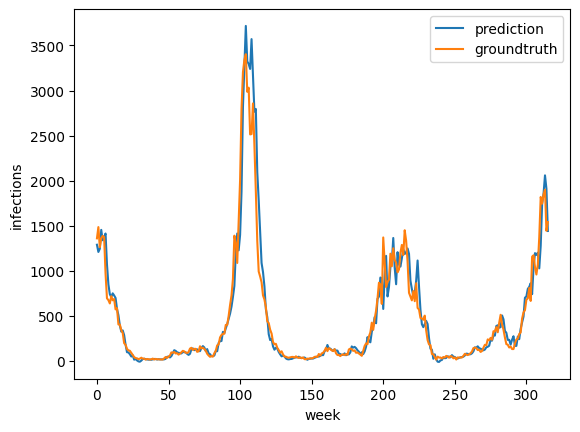

In [130]:
# MLP Model Evaluation
predictions, groundtruth = plot(MLP_model, test_loader)

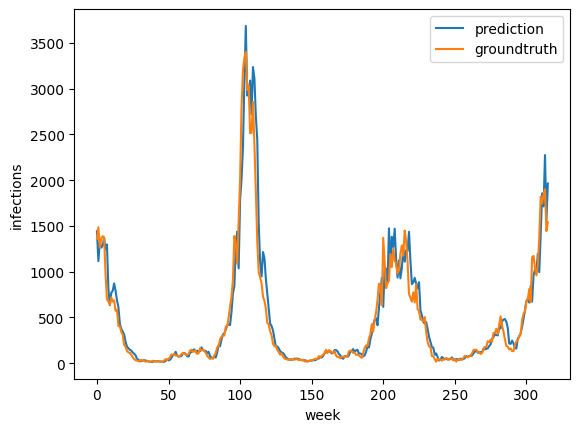

In [131]:
# CNN Model Evaluation
predictions, groundtruth = plot(CNN_model, test_loader)

In [132]:
# learned Kernel weights
print("\nKernel (Weights):")
print(CNN_model.conv1.weight.detach().cpu().numpy()[0])


Kernel (Weights):
[[-0.5222397   0.3769112   0.31099838]]


# Homework

1. With a deeper and larger kernel, CNN is able to capture more global information. Try changing the hyperparameters of CNN(kernel size, stride, and padding) and see how the results change. (see 4. Building CNN Model)
<!-- https://lukeguerdan.com/blog/2019/intro-to-tcns/ -->

<img src="https://drive.google.com/uc?id=11zgPhFec_MPB5Zau3NeAO_lkHCJk9Qy7" alt="mlp" width="500" height="300">
<!-- <img src="receptive_field.png" alt="mlp" width="500" height="300"> -->

2. Try to explore the relation between lookback-window-size/horizon and the model performance. (see 0. Import packages)
3. Mean Square Error is used as the default metric. Try using other loss functions like RMSE, MAE, L1 loss, etc. (see the criterion function in 5. Model Training and 6. Model Evaluation)

## HW1

In [133]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# CNN with more hyperparameters
class CNN1D(nn.Module):
    def __init__(self, lookback, horizon, hidden_sizes=[16, 32, 128], kernel_size=3, stride=1, padding=1, pool_kernel_size=2, pool_stride=2):
        super(CNN1D, self).__init__()
        self.lookback = lookback  # Number of past time steps to consider (history)
        self.horizon = horizon   # Number of future time steps to predict

        # First convolutional layer with flexible hyperparameters
        self.conv1 = nn.Conv1d(in_channels=1,
                               out_channels=hidden_sizes[0],
                               kernel_size=kernel_size,
                               stride=stride,
                               padding=padding)

        # Second convolutional layer with flexible hyperparameters
        self.conv2 = nn.Conv1d(in_channels=hidden_sizes[0],
                               out_channels=hidden_sizes[1],
                               kernel_size=kernel_size,
                               stride=stride,
                               padding=padding)

        # Max Pooling layer with flexible hyperparameters
        self.pool = nn.MaxPool1d(kernel_size=pool_kernel_size,
                                 stride=pool_stride,
                                 padding=0)
        self.relu = nn.ReLU()             # ReLU activation function

        dummy_input = torch.randn(1, 1, lookback)
        dummy_output_conv1 = self.relu(self.conv1(dummy_input))
        dummy_output_pool1 = self.pool(dummy_output_conv1)
        dummy_output_conv2 = self.relu(self.conv2(dummy_output_pool1))
        dummy_output_pool2 = self.pool(dummy_output_conv2)
        flattened_size = dummy_output_pool2.view(dummy_output_pool2.size(0), -1).size(1)


        self.fc1 = nn.Linear(hidden_sizes[1] * (flattened_size // hidden_sizes[1]), hidden_sizes[2]) # first linear layer
        self.fc2 = nn.Linear(hidden_sizes[2], horizon) # second linear layer

        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        # feature extrction using convolution layers
        x = x.unsqueeze(1)
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        # flatten and perform prediction using fully connected layers
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

# Example initialization with different hyperparameters
# CNN_model = CNN1D(lookback, horizon, hidden_sizes=[16,32,128], kernel_size=5, stride=2, padding=2, pool_kernel_size=3, pool_stride=3).cuda()

# Keep the original hyperparameters for now, but the class is ready for experimentation
CNN_model = CNN1D(lookback, horizon, hidden_sizes=[16,32,128]).cuda()

Training CNN model with new hyperparameters:
Epoch [1/100], Loss: 8745.552871905405


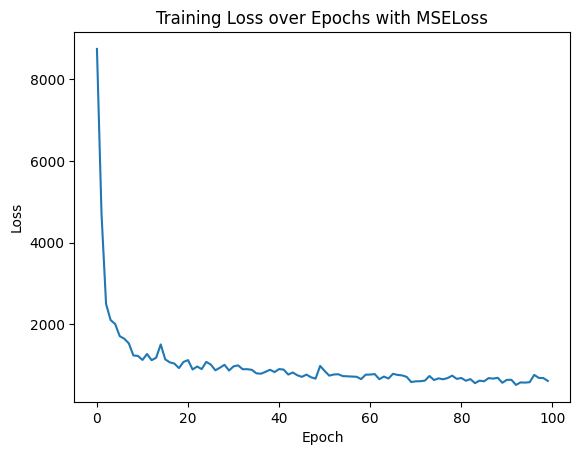


Evaluating CNN model with new hyperparameters:
Evaluation: 887.7698295206964

Plotting CNN model predictions with new hyperparameters:


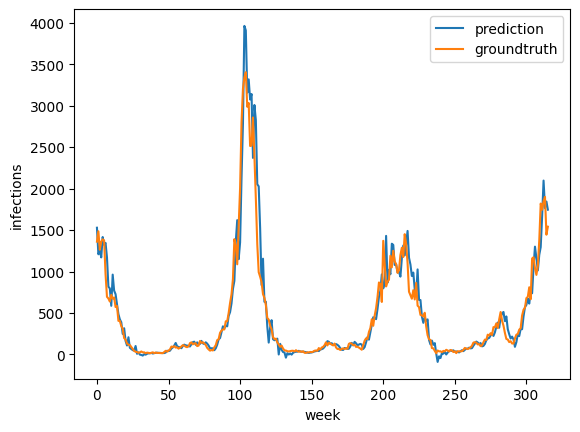

(tensor([ 1.5278e+03,  1.2075e+03,  1.2550e+03,  1.1703e+03,  1.4157e+03,
          1.3213e+03,  1.3451e+03,  1.1708e+03,  8.1728e+02,  7.9647e+02,
          5.8665e+02,  9.6250e+02,  7.6945e+02,  7.2687e+02,  6.0412e+02,
          4.8621e+02,  4.2269e+02,  3.8873e+02,  2.4664e+02,  3.1643e+02,
          1.6326e+02,  1.0786e+02,  2.0737e+02,  7.9830e+01,  6.5300e+01,
          5.1966e+01,  4.6906e+01,  1.0212e+02,  8.1262e+00,  2.5501e+01,
         -2.3852e+00, -5.8555e+00, -1.3437e+01,  3.3061e+00, -2.8304e+00,
          8.3100e+00,  1.3541e+01,  1.3821e+01,  1.8839e+01,  1.1207e+01,
          1.6355e+01,  1.9244e+01,  2.1722e+01,  1.8442e+01,  1.9165e+01,
          1.7304e+01,  1.7109e+01,  1.6853e+01,  2.2981e+01,  4.4382e+01,
          4.0724e+01,  4.5333e+01,  7.0527e+01,  8.4532e+01,  1.0783e+02,
          1.3864e+02,  9.9151e+01,  9.0237e+01,  8.5532e+01,  7.5284e+01,
          1.0201e+02,  1.1843e+02,  1.0948e+02,  1.0717e+02,  1.0056e+02,
          9.6445e+01,  1.2446e+02,  1.

In [134]:
# Initialize a new CNN model with different hyperparameters
# Example: increased kernel size and stride, adjusted padding
cnn_model_experiment = CNN1D(lookback, horizon, hidden_sizes=[16, 32, 128], kernel_size=5, stride=1, padding=2, pool_kernel_size=2, pool_stride=2).cuda()

# Train the new CNN model
print("Training CNN model with new hyperparameters:")
cnn_model_experiment = train(cnn_model_experiment, epochs=100)

# Evaluate the new CNN model on the test set
print("\nEvaluating CNN model with new hyperparameters:")
criterion = nn.MSELoss()
test_preds_experiment, test_gt_experiment = test(cnn_model_experiment, test_loader, criterion)

# Optionally, plot the results
print("\nPlotting CNN model predictions with new hyperparameters:")
plot(cnn_model_experiment, test_loader)


Training CNN model with kernel size = 3
Epoch [1/100], Loss: 7083.035621180069


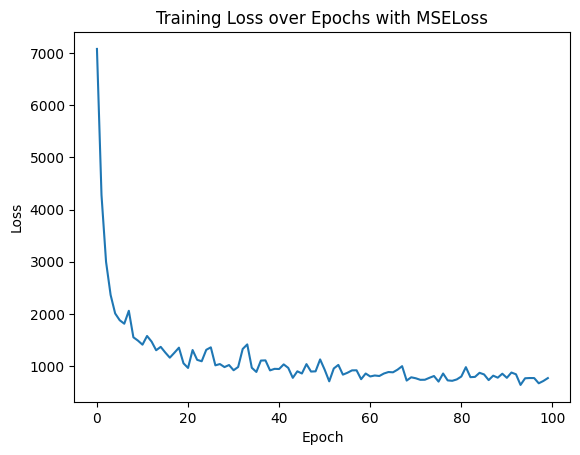


Evaluating CNN model with kernel size = 3
Evaluation: 879.0780569631842

Training CNN model with kernel size = 5
Epoch [1/100], Loss: 6938.578368013326


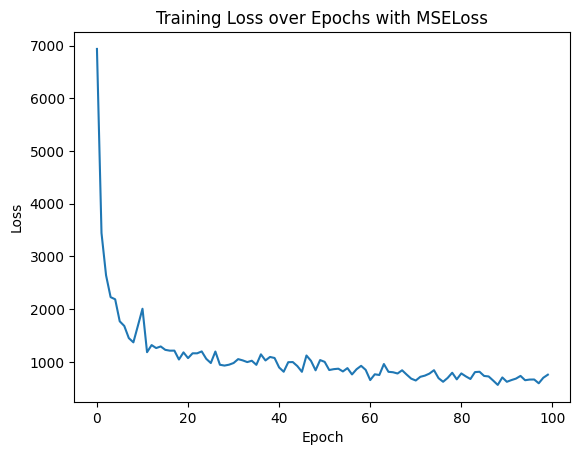


Evaluating CNN model with kernel size = 5
Evaluation: 1495.966191641892

Training CNN model with kernel size = 7
Epoch [1/100], Loss: 6937.97510442004


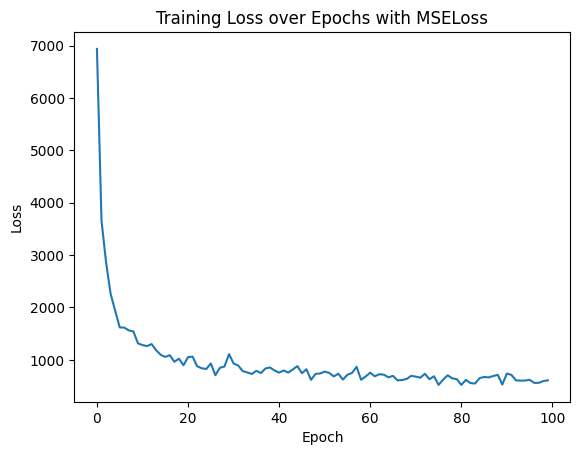


Evaluating CNN model with kernel size = 7
Evaluation: 875.1613118135476


In [135]:
kernel_sizes = [3, 5, 7]  # Experiment with different kernel sizes
results = {}

for kernel_size in kernel_sizes:
    print(f"\nTraining CNN model with kernel size = {kernel_size}")
    # Initialize CNN model with different kernel sizes
    cnn_model_experiment = CNN1D(lookback, horizon, hidden_sizes=[16, 32, 128], kernel_size=kernel_size, padding=kernel_size // 2).cuda() # Adjust padding to maintain output size

    # Train the CNN model
    cnn_model_experiment = train(cnn_model_experiment, epochs=100) # Train for fewer epochs for demonstration

    # Evaluate the CNN model on the test set
    print(f"\nEvaluating CNN model with kernel size = {kernel_size}")
    criterion = nn.MSELoss()
    test_preds_experiment, test_gt_experiment = test(cnn_model_experiment, test_loader, criterion)

    # Store the results
    results[kernel_size] = test_preds_experiment, test_gt_experiment, criterion(test_preds_experiment, test_gt_experiment).item()

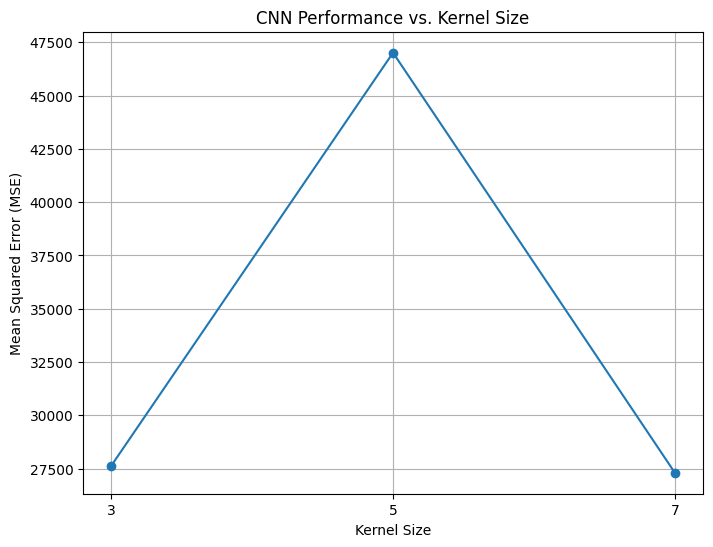

In [136]:
import matplotlib.pyplot as plt

# Extract kernel sizes and MSE from the results dictionary
kernel_sizes = sorted(results.keys())
mse_values = [results[k][2] for k in kernel_sizes]

# Plot the MSE values against the kernel sizes
plt.figure(figsize=(8, 6))
plt.plot(kernel_sizes, mse_values, marker='o', linestyle='-')
plt.xlabel('Kernel Size')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('CNN Performance vs. Kernel Size')
plt.xticks(kernel_sizes)
plt.grid(True)
plt.show()

### Explore Lookback/Horizon Relation


Training with Lookback: 8, Horizon: 1
Training MLP model...
Epoch [1/100], Loss: 2778.7941230793845


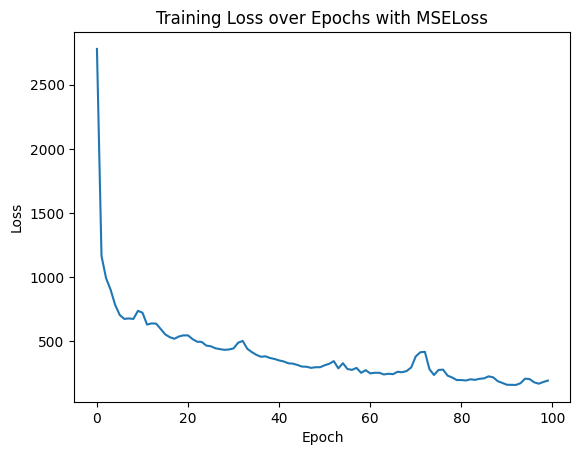

Evaluating MLP model...
Evaluation: 889.9126879845137
MLP Test MSE: 24787.703125

Training CNN model...
Epoch [1/100], Loss: 6099.94179078742


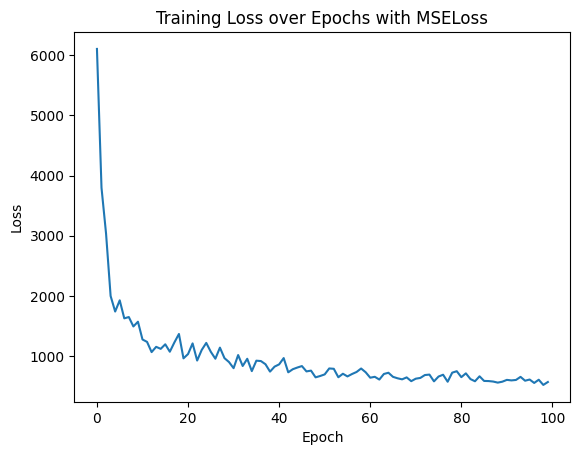

Evaluating CNN model...
Evaluation: 1136.652961683862
CNN Test MSE: 23092.578125

Training with Lookback: 16, Horizon: 1
Training MLP model...
Epoch [1/100], Loss: 4090.2032993286457


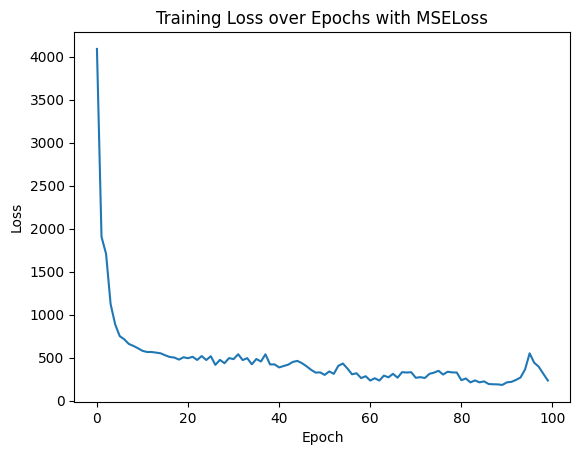

Evaluating MLP model...
Evaluation: 888.8736406157288
MLP Test MSE: 27574.62109375

Training CNN model...
Epoch [1/100], Loss: 7666.039656103129


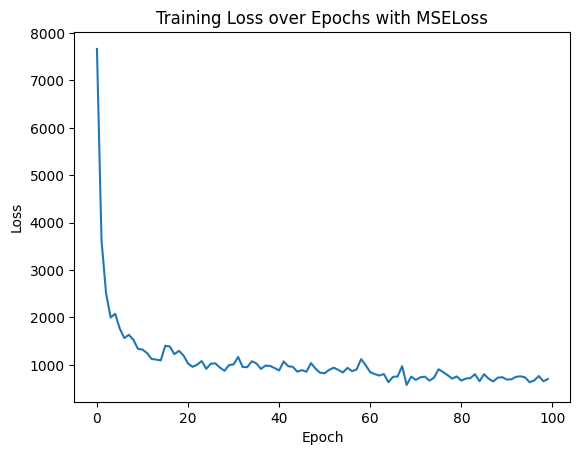

Evaluating CNN model...
Evaluation: 831.3624576616891
CNN Test MSE: 25743.837890625

Training with Lookback: 32, Horizon: 1
Training MLP model...
Epoch [1/100], Loss: 5925.677182919895


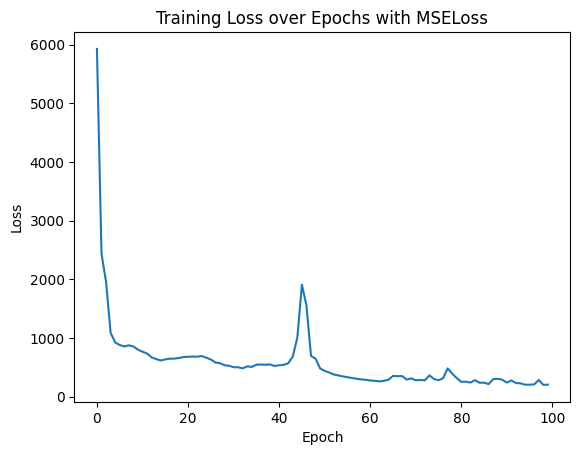

Evaluating MLP model...
Evaluation: 684.975224609375
MLP Test MSE: 19121.291015625

Training CNN model...
Epoch [1/100], Loss: 8024.6692264690555


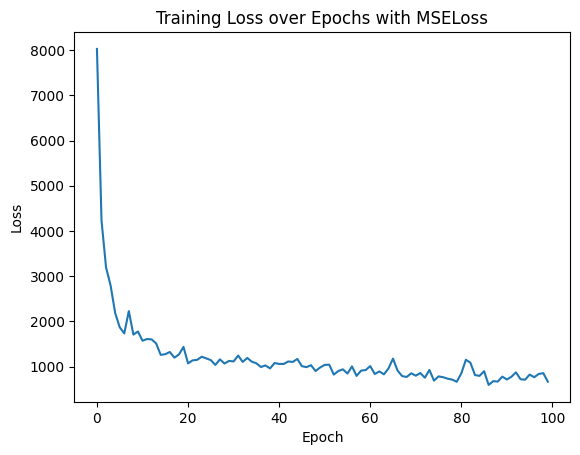

Evaluating CNN model...
Evaluation: 941.1894673665364
CNN Test MSE: 26085.708984375

Training with Lookback: 16, Horizon: 3
Training MLP model...
Epoch [1/100], Loss: 5459.159061492435


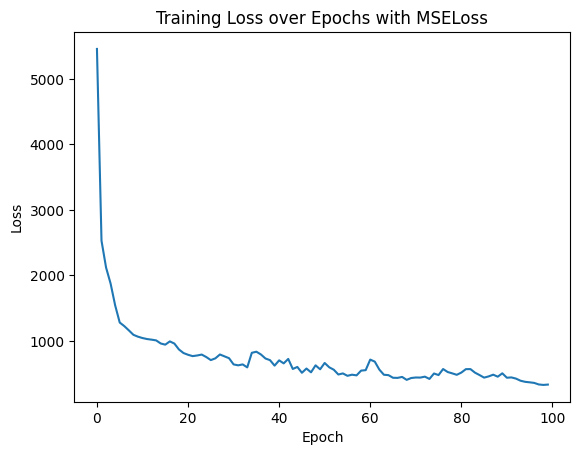

Evaluating MLP model...
Evaluation: 1099.3354597152418
MLP Test MSE: 33119.98828125

Training CNN model...
Epoch [1/100], Loss: 9435.231702855024


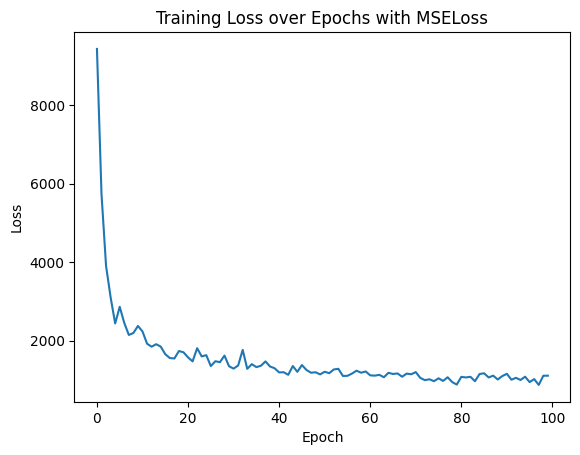

Evaluating CNN model...
Evaluation: 1499.0300109280142
CNN Test MSE: 46326.22265625

Training with Lookback: 16, Horizon: 5
Training MLP model...
Epoch [1/100], Loss: 7169.300610610598


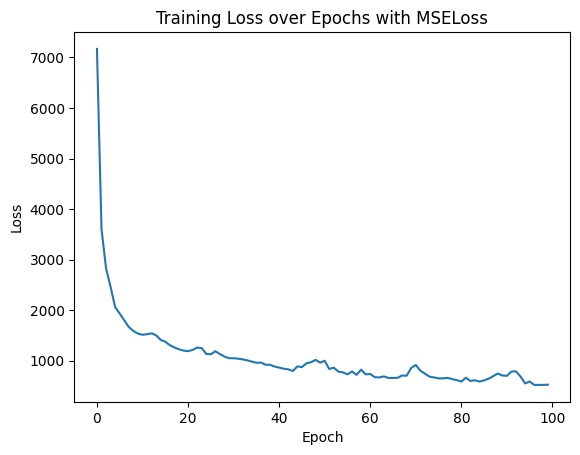

Evaluating MLP model...
Evaluation: 1629.3651201297075
MLP Test MSE: 47234.12890625

Training CNN model...
Epoch [1/100], Loss: 10505.086895282451


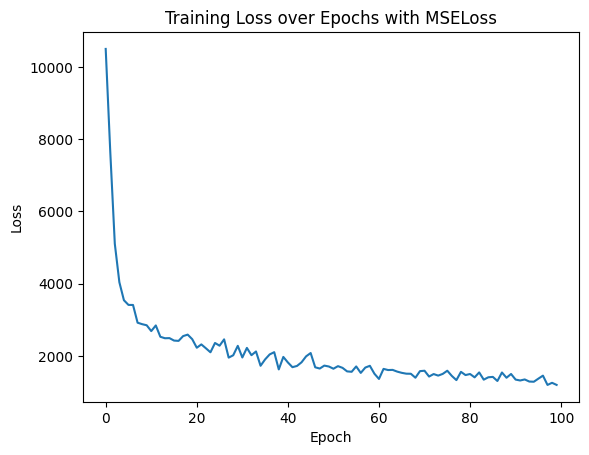

Evaluating CNN model...
Evaluation: 2533.9963961870244
CNN Test MSE: 77443.1484375

Lookback/Horizon Experiment Results:
Lookback: 8, Horizon: 1, MLP MSE: 24787.70, CNN MSE: 23092.58
Lookback: 16, Horizon: 1, MLP MSE: 27574.62, CNN MSE: 25743.84
Lookback: 32, Horizon: 1, MLP MSE: 19121.29, CNN MSE: 26085.71
Lookback: 16, Horizon: 3, MLP MSE: 33119.99, CNN MSE: 46326.22
Lookback: 16, Horizon: 5, MLP MSE: 47234.13, CNN MSE: 77443.15


In [137]:
# Experiment with different lookback and horizon values
lookback_horizon_experiments = [
    {'lookback': 8, 'horizon': 1},
    {'lookback': 16, 'horizon': 1}, # Original values
    {'lookback': 32, 'horizon': 1},
    {'lookback': 16, 'horizon': 3},
    {'lookback': 16, 'horizon': 5},
]

results_lh = {}

for exp_config in lookback_horizon_experiments:
    current_lookback = exp_config['lookback']
    current_horizon = exp_config['horizon']
    print(f"\nTraining with Lookback: {current_lookback}, Horizon: {current_horizon}")

    # Re-create datasets and dataloaders with new lookback and horizon
    train_dataset = measle_dataset(train_data, current_lookback, current_horizon)
    test_dataset = measle_dataset(test_data, current_lookback, current_horizon)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    # Initialize and train MLP model
    print("Training MLP model...")
    mlp_model_experiment = MLP(current_lookback, current_horizon).cuda()
    mlp_model_experiment = train(mlp_model_experiment, epochs=100) # Train for fewer epochs for demonstration

    # Evaluate MLP model
    criterion = nn.MSELoss()
    print("Evaluating MLP model...")
    test_preds_mlp, test_gt_mlp = test(mlp_model_experiment, test_loader, criterion)
    mlp_mse = criterion(test_preds_mlp, test_gt_mlp).item()
    print(f"MLP Test MSE: {mlp_mse}")

    # Initialize and train CNN model
    print("\nTraining CNN model...")
    cnn_model_experiment = CNN1D(current_lookback, current_horizon).cuda()
    cnn_model_experiment = train(cnn_model_experiment, epochs=100) # Train for fewer epochs for demonstration

    # Evaluate CNN model
    print("Evaluating CNN model...")
    criterion = nn.MSELoss()
    test_preds_cnn, test_gt_cnn = test(cnn_model_experiment, test_loader, criterion)
    cnn_mse = criterion(test_preds_cnn, test_gt_cnn).item()
    print(f"CNN Test MSE: {cnn_mse}")

    results_lh[(current_lookback, current_horizon)] = {'MLP_MSE': mlp_mse, 'CNN_MSE': cnn_mse}

print("\nLookback/Horizon Experiment Results:")
for config, mse_results in results_lh.items():
    print(f"Lookback: {config[0]}, Horizon: {config[1]}, MLP MSE: {mse_results['MLP_MSE']:.2f}, CNN MSE: {mse_results['CNN_MSE']:.2f}")


Experimenting with MSELoss
Training MLP model...
Epoch [1/100], Loss: 5568.290883840869


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([32, 5])) that is different to the input size (torch.Size([32, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([18, 5])) that is different to the input size (torch.Size([18, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


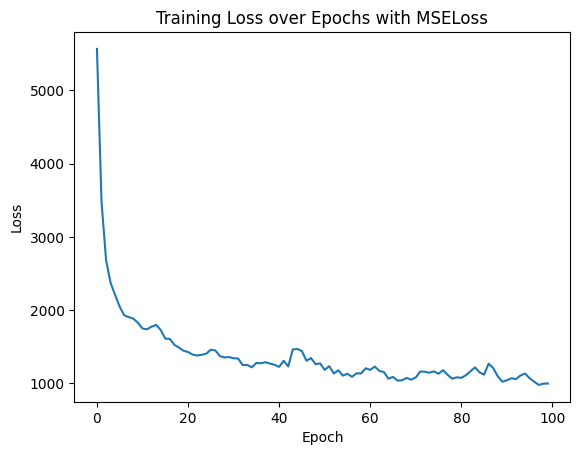

Evaluating MLP model...
Evaluation: 1664.4181531270344
MLP Test MSELoss: 49478.18359375

Training CNN model...
Epoch [1/100], Loss: 9723.481649626472


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([24, 5])) that is different to the input size (torch.Size([24, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([312, 5])) that is different to the input size (torch.Size([312, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


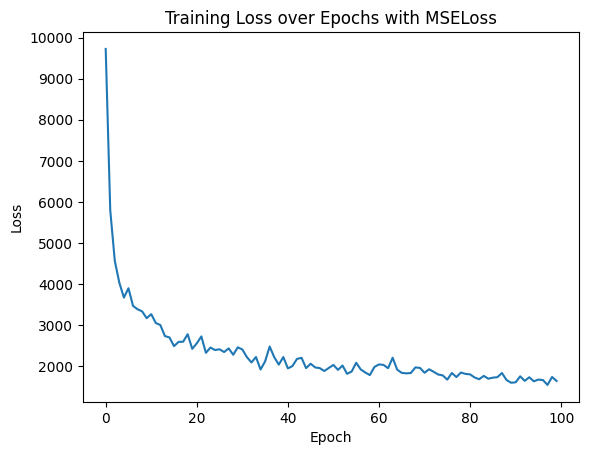

Evaluating CNN model...
Evaluation: 2398.6088575705503
CNN Test MSELoss: 72873.9921875

Experimenting with L1Loss
Training MLP model...
Epoch [1/100], Loss: 8.514697641529517


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:128: UserWarning: Using a target size (torch.Size([32, 5])) that is different to the input size (torch.Size([32, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.l1_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:128: UserWarning: Using a target size (torch.Size([18, 5])) that is different to the input size (torch.Size([18, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.l1_loss(input, target, reduction=self.reduction)


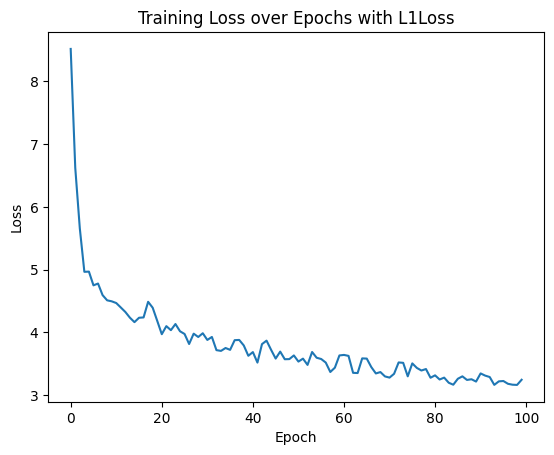

Evaluating MLP model...
Evaluation: 4.294711161882449
MLP Test L1Loss: 131.02667236328125

Training CNN model...
Epoch [1/100], Loss: 9.855368191746882


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:128: UserWarning: Using a target size (torch.Size([24, 5])) that is different to the input size (torch.Size([24, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.l1_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:128: UserWarning: Using a target size (torch.Size([312, 5])) that is different to the input size (torch.Size([312, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.l1_loss(input, target, reduction=self.reduction)


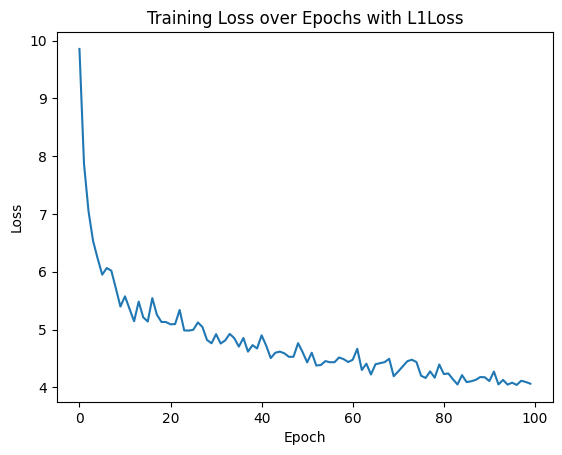

Evaluating CNN model...
Evaluation: 4.388598900574904
CNN Test L1Loss: 133.4581298828125

Loss Function Experiment Results:
Loss Function: MSELoss, MLP Loss: 49478.18, CNN Loss: 72873.99
Loss Function: L1Loss, MLP Loss: 131.03, CNN Loss: 133.46


In [138]:
loss_functions = {
    'MSELoss': nn.MSELoss(),
    'L1Loss': nn.L1Loss()
}

results_loss = {}

for loss_name, criterion in loss_functions.items():
    print(f"\nExperimenting with {loss_name}")

    # Re-initialize models to train from scratch with the new loss function
    mlp_model_experiment = MLP(lookback, horizon).cuda()
    cnn_model_experiment = CNN1D(lookback, horizon).cuda()

    # Train MLP model
    print("Training MLP model...")
    mlp_model_experiment = train(mlp_model_experiment, epochs=100, criterion=criterion) # Train for fewer epochs

    # Evaluate MLP model
    print("Evaluating MLP model...")
    test_preds_mlp, test_gt_mlp = test(mlp_model_experiment, test_loader, criterion)
    mlp_loss_value = criterion(test_preds_mlp, test_gt_mlp).item()
    print(f"MLP Test {loss_name}: {mlp_loss_value}")

    # Train CNN model
    print("\nTraining CNN model...")
    cnn_model_experiment = train(cnn_model_experiment, epochs=100, criterion=criterion) # Train for fewer epochs

    # Evaluate CNN model
    print("Evaluating CNN model...")
    test_preds_cnn, test_gt_cnn = test(cnn_model_experiment, test_loader, criterion)
    cnn_loss_value = criterion(test_preds_cnn, test_gt_cnn).item()
    print(f"CNN Test {loss_name}: {cnn_loss_value}")

    results_loss[loss_name] = {'MLP_Loss': mlp_loss_value, 'CNN_Loss': cnn_loss_value}

print("\nLoss Function Experiment Results:")
for loss_name, loss_results in results_loss.items():
    print(f"Loss Function: {loss_name}, MLP Loss: {loss_results['MLP_Loss']:.2f}, CNN Loss: {loss_results['CNN_Loss']:.2f}")